In [4]:
{
 "cells": [],
 "metadata": {
  "kernelspec": {
   "display_name": "Python 3",
   "language": "python",
   "name": "python3"
  }
 },
 "nbformat": 4,
 "nbformat_minor": 4
}

{'cells': [],
 'metadata': {'kernelspec': {'display_name': 'Python 3',
   'language': 'python',
   'name': 'python3'}},
 'nbformat': 4,
 'nbformat_minor': 4}

In [5]:
print("hello_word")

hello_word


In [6]:
import subprocess


In [7]:
from hdfs import InsecureClient
import json

# Connexion à HDFS
hdfs_client = InsecureClient('http://namenode:9870', user='etudiant')

# Chemin HDFS
hdfs_output_path = '/user/etudiant/crypto/raw/historique_gold/yfinance_raw_historique.json'


# Lire et charger les données ligne par ligne
data = []
with hdfs_client.read(hdfs_output_path) as reader:
    for line in reader:
        try:
            obj = json.loads(line.strip())
            data.append(obj)
        except json.JSONDecodeError as e:
            print(f"Erreur de décodage pour la ligne : {line.strip()} - {e}")

print("Nombre d'objets lus :", len(data))
print("5 premiers objets :", data[:5])

Nombre d'objets lus : 5825
5 premiers objets : [{'datetime': '2002-01-02T00:00:00.000Z', 'open_price': 278.8999938964844, 'high_price': 278.8999938964844, 'low_price': 278.8999938964844, 'close_price': 278.8999938964844, 'volume': 2, 'asset': 'GOLD'}, {'datetime': '2002-01-03T00:00:00.000Z', 'open_price': 278.20001220703125, 'high_price': 278.20001220703125, 'low_price': 278.20001220703125, 'close_price': 278.20001220703125, 'volume': 2, 'asset': 'GOLD'}, {'datetime': '2002-01-04T00:00:00.000Z', 'open_price': 278.8999938964844, 'high_price': 278.8999938964844, 'low_price': 278.8999938964844, 'close_price': 278.8999938964844, 'volume': 2, 'asset': 'GOLD'}, {'datetime': '2002-01-07T00:00:00.000Z', 'open_price': 278.6000061035156, 'high_price': 279.0, 'low_price': 278.6000061035156, 'close_price': 278.6000061035156, 'volume': 1, 'asset': 'GOLD'}, {'datetime': '2002-01-08T00:00:00.000Z', 'open_price': 278.8999938964844, 'high_price': 278.8999938964844, 'low_price': 278.8999938964844, 'clos

In [8]:
import pandas as pd 

In [9]:
df = pd.DataFrame(data)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

In [10]:
df

,open_price,high_price,low_price,close_price,volume,asset
datetime,,,,,,
2002-01-02 00:00:00+00:00,278.899994,278.899994,278.899994,278.899994,2,GOLD
2002-01-03 00:00:00+00:00,278.200012,278.200012,278.200012,278.200012,2,GOLD
2002-01-04 00:00:00+00:00,278.899994,278.899994,278.899994,278.899994,2,GOLD
2002-01-07 00:00:00+00:00,278.600006,279.000000,278.600006,278.600006,1,GOLD
2002-01-08 00:00:00+00:00,278.899994,278.899994,278.899994,278.899994,1,GOLD
...,...,...,...,...,...,...
2025-03-10 00:00:00+00:00,2910.100098,2915.100098,2880.199951,2891.000000,55,GOLD
2025-03-11 00:00:00+00:00,2884.399902,2916.699951,2880.399902,2912.899902,197,GOLD
2025-03-12 00:00:00+00:00,2912.000000,2939.100098,2910.000000,2939.100098,213,GOLD


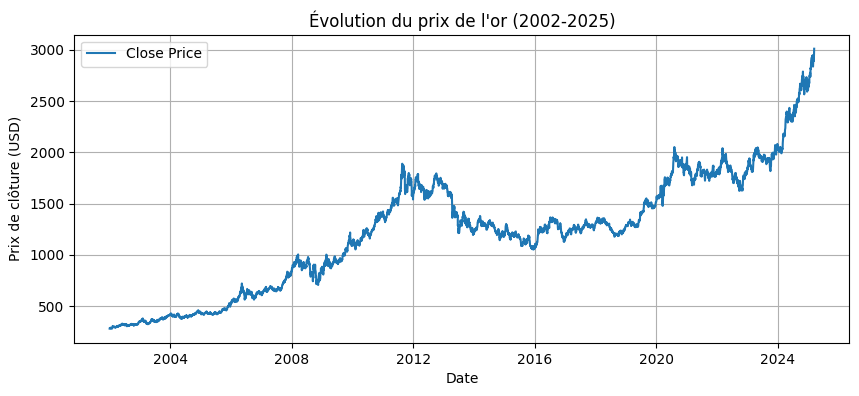

In [11]:
'''l'évolution des prix de l'or sur la période (2002-2025).'''
import matplotlib.pyplot as plt
# Convertir la colonne datetime en format datetime

# Tracer le prix de clôture (close_price) au fil du temps
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['close_price'], label='Close Price')
plt.title('Évolution du prix de l\'or (2002-2025)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.grid(True)
plt.legend()
plt.show()

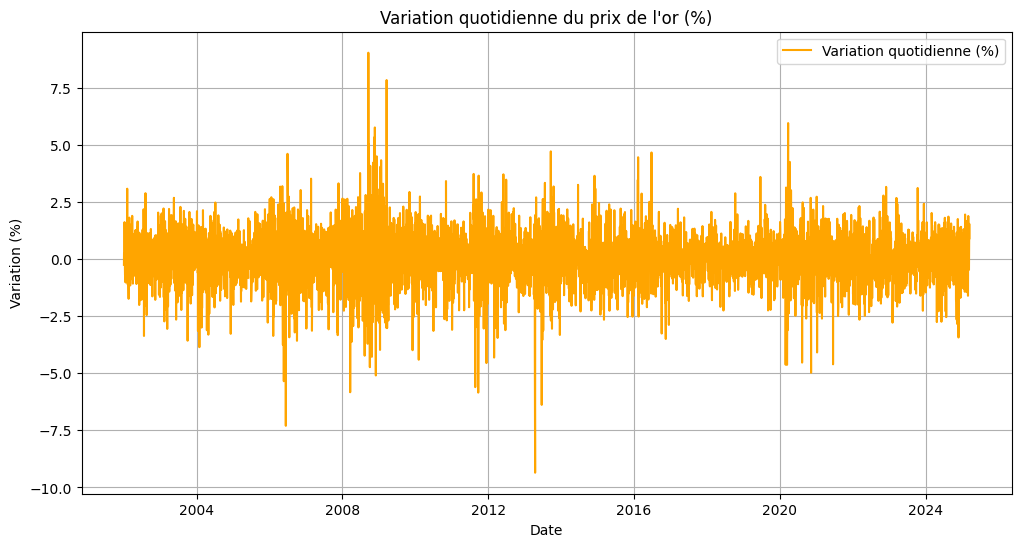

Statistiques des variations quotidiennes :
count    5824.000000
mean        0.046874
std         1.095693
min        -9.353766
25%        -0.474719
50%         0.052835
75%         0.638309
max         9.027685
Name: daily_change_pct, dtype: float64


In [12]:
#les variations quotidiennes des 
# Calculer la variation quotidienne (différence entre close_price d'un jour à l'autre)
df['daily_change'] = df['close_price'].diff()

# Calculer le pourcentage de variation quotidienne
df['daily_change_pct'] = df['close_price'].pct_change() * 100

# Tracer les variations quotidiennes
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['daily_change_pct'], label='Variation quotidienne (%)', color='orange')
plt.title('Variation quotidienne du prix de l\'or (%)')
plt.xlabel('Date')
plt.ylabel('Variation (%)')
plt.grid(True)
plt.legend()
plt.show()

# Statistiques de base
print("Statistiques des variations quotidiennes :")
print(df['daily_change_pct'].describe())

Corrélation entre le prix et le volume :
             close_price    volume
close_price     1.000000  0.034185
volume          0.034185  1.000000


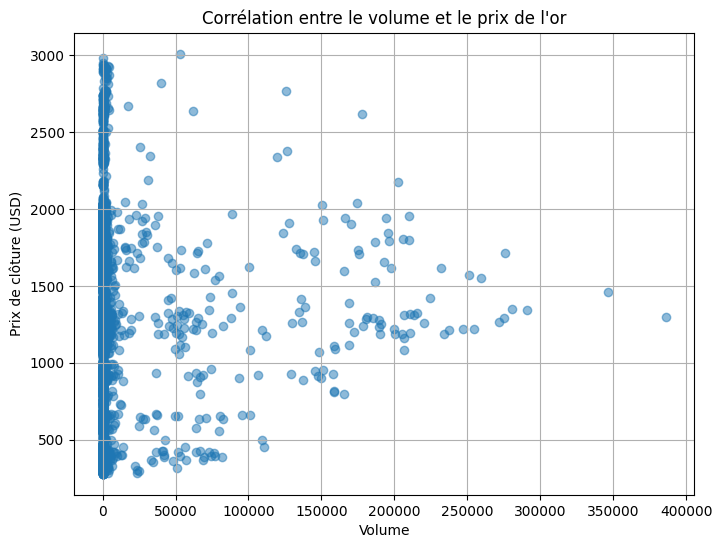

In [13]:
#le volume d'échange influence les variations de prix
# Calculer la corrélation
correlation = df[['close_price', 'volume']].corr()
print("Corrélation entre le prix et le volume :")
print(correlation)

# Tracer un nuage de points (scatter plot)
plt.figure(figsize=(8, 6))
plt.scatter(df['volume'], df['close_price'], alpha=0.5)
plt.title('Corrélation entre le volume et le prix de l\'or')
plt.xlabel('Volume')
plt.ylabel('Prix de clôture (USD)')
plt.grid(True)
plt.show()

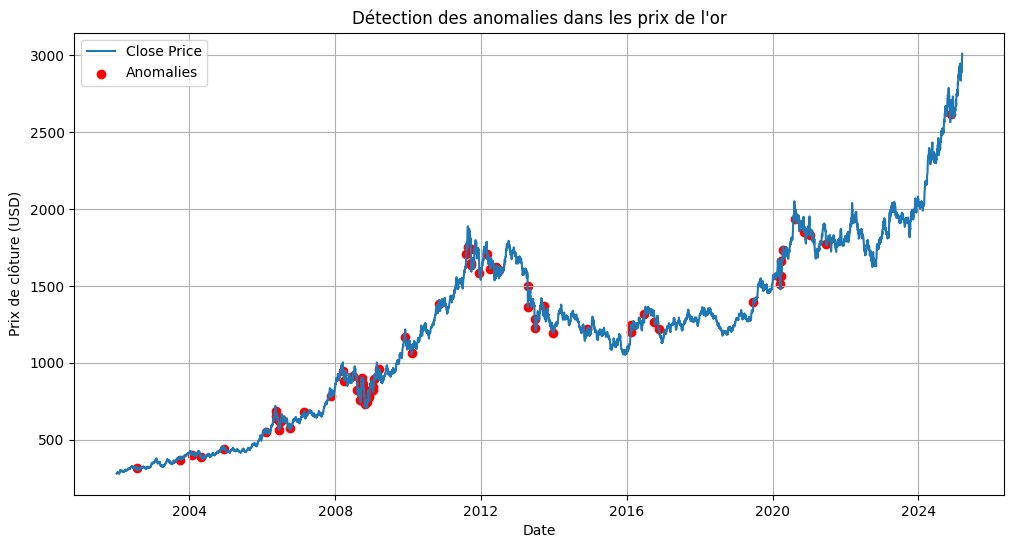

DatetimeIndex(['2002-07-23 00:00:00+00:00', '2003-10-03 00:00:00+00:00',
               '2004-01-29 00:00:00+00:00', '2004-04-28 00:00:00+00:00',
               '2004-12-08 00:00:00+00:00', '2006-02-07 00:00:00+00:00',
               '2006-05-15 00:00:00+00:00', '2006-05-19 00:00:00+00:00',
               '2006-05-24 00:00:00+00:00', '2006-06-13 00:00:00+00:00',
               '2006-06-30 00:00:00+00:00', '2006-07-18 00:00:00+00:00',
               '2006-10-03 00:00:00+00:00', '2007-02-21 00:00:00+00:00',
               '2007-11-15 00:00:00+00:00', '2008-03-19 00:00:00+00:00',
               '2008-04-01 00:00:00+00:00', '2008-06-26 00:00:00+00:00',
               '2008-08-11 00:00:00+00:00', '2008-09-10 00:00:00+00:00',
               '2008-09-17 00:00:00+00:00', '2008-09-18 00:00:00+00:00',
               '2008-09-19 00:00:00+00:00', '2008-09-22 00:00:00+00:00',
               '2008-10-02 00:00:00+00:00', '2008-10-06 00:00:00+00:00',
               '2008-10-16 00:00:00+00:00', '2008-1

In [14]:
#Identifier les jours avec des variations inhabituelles
# Calculer les écarts-types pour détecter les anomalies
mean_change = df['daily_change_pct'].mean()
std_change = df['daily_change_pct'].std()
threshold = 3  # Seuil de 3 écarts-types pour définir une anomalie

# Identifier les anomalies
df['anomaly'] = df['daily_change_pct'].apply(lambda x: abs(x - mean_change) > threshold * std_change)

# Tracer les anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close_price'], label='Close Price')
plt.scatter(df[df['anomaly']].index, df[df['anomaly']]['close_price'], color='red', label='Anomalies', marker='o')
plt.title('Détection des anomalies dans les prix de l\'or')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()
plt.grid(True)
plt.show()
print(df[df['anomaly']].index)

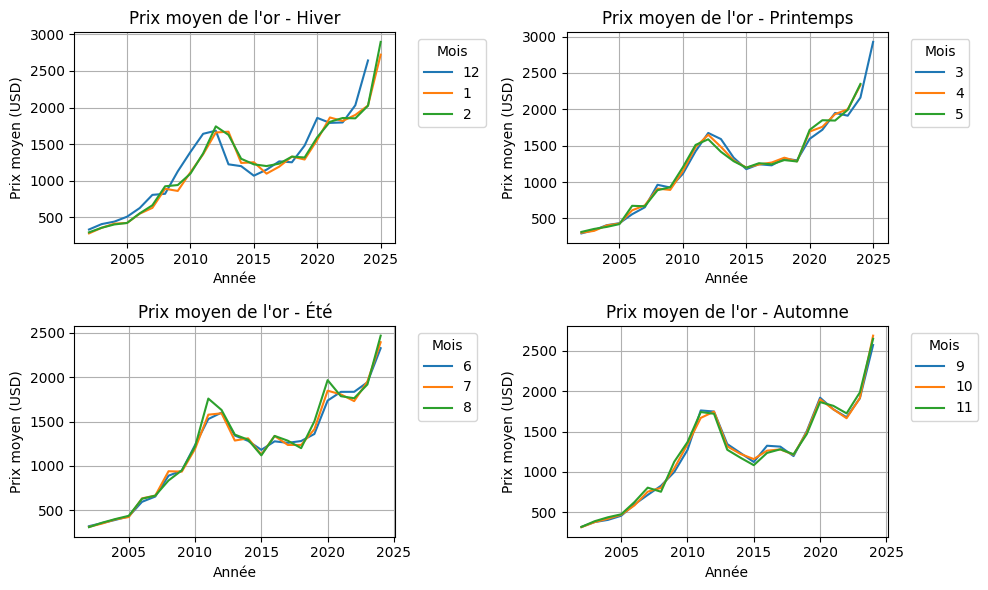

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraire l'année et le mois
df['year'] = df.index.year
df['month'] = df.index.month

# Calculer le prix moyen par mois pour chaque année
monthly_avg = df.groupby(['year', 'month'])['close_price'].mean().unstack()

# Définir les saisons avec leurs mois respectifs
seasons = {
    "Hiver": [12, 1, 2],
    "Printemps": [3, 4, 5],
    "Été": [6, 7, 8],
    "Automne": [9, 10, 11]
}

# Créer 4 sous-graphiques pour chaque saison
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for i, (season, months) in enumerate(seasons.items()):
    ax = axes[i // 2, i % 2]  # Position dans la grille 2x2
    monthly_avg[months].plot(ax=ax)
    ax.set_title(f'Prix moyen de l\'or - {season}')
    ax.set_xlabel('Année')
    ax.set_ylabel('Prix moyen (USD)')
    ax.legend(title='Mois', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True)

plt.tight_layout()
plt.show()


In [16]:
#preparation pour le modele
# Moyennes mobiles
df['ma_5'] = df['close_price'].rolling(window=5).mean()  # Moyenne mobile sur 5 jours
df['ma_20'] = df['close_price'].rolling(window=20).mean()  # Moyenne mobile sur 20 jours

# RSI
def calculate_rsi(data, periods=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi'] = calculate_rsi(df['close_price'])

# Lags (valeurs passées)
for lag in range(1, 4):  # Ajouter les 3 derniers jours
    df[f'lag_{lag}'] = df['close_price'].shift(lag)

# Supprimer les lignes avec des valeurs manquantes (NaN)
df = df.dropna()

In [17]:
from sklearn.model_selection import train_test_split

# Définir les features et la cible
features = ['open_price', 'high_price', 'low_price', 'volume', 'ma_5', 'ma_20', 'rsi', 'lag_1', 'lag_2', 'lag_3']
X = df[features]
y = df['close_price'].shift(-1)  # Prix du jour suivant

# Supprimer la dernière ligne (car la cible est NaN)
X = X.iloc[:-1]
y = y.iloc[:-1]

# Diviser en ensembles d'entraînement et de test (sans mélanger, pour respecter l'ordre temporel)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

ModuleNotFoundError: No module named 'sklearn'

Régression linéaire - MSE: 396.02, R²: 1.00


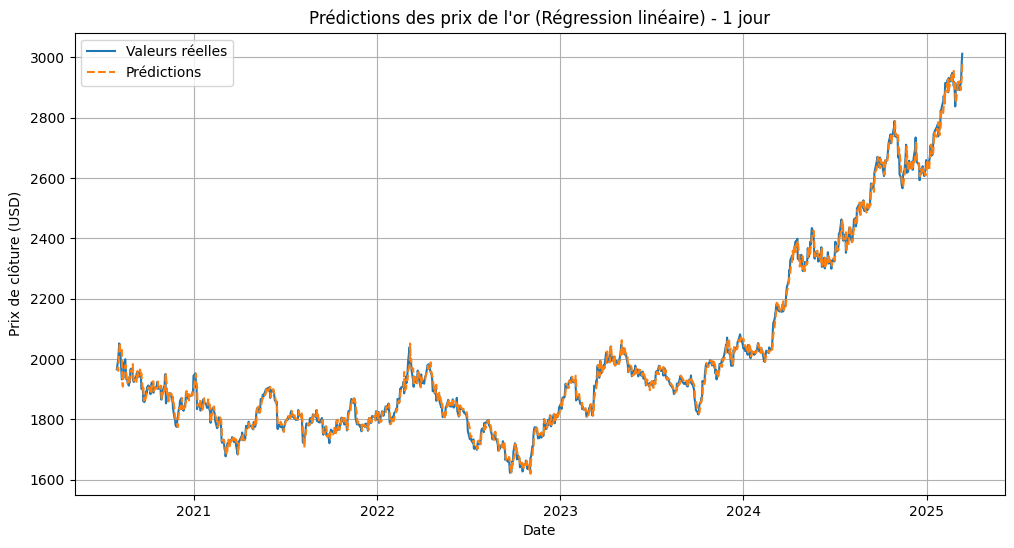

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Entraîner le modèle
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Prédire sur l'ensemble de test
y_pred_lr = model_lr.predict(X_test)

# Évaluer le modèle
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Régression linéaire - MSE: {mse_lr:.2f}, R²: {r2_lr:.2f}")

# Tracer les prédictions
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Valeurs réelles')
plt.plot(y_test.index, y_pred_lr, label='Prédictions', linestyle='--')
plt.title('Prédictions des prix de l\'or (Régression linéaire) - 1 jour')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Normaliser les données
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['close_price']])

# Créer des séquences pour LSTM (par exemple, utiliser les 60 derniers jours pour prédire le suivant)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Utiliser 60 jours pour prédire le suivant
X, y = create_sequences(scaled_data, seq_length)

# Diviser en ensembles d'entraînement et de test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

2025-03-14 10:12:44.969451: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-14 10:12:45.077361: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-14 10:12:45.612741: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-14 10:12:45.612810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-14 10:12:45.676939: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

Epoch 1/10
130/130 [==============================] - 17s 100ms/step - loss: 0.0033 - val_loss: 1.6951e-04
Epoch 2/10
130/130 [==============================] - 11s 83ms/step - loss: 6.1407e-04 - val_loss: 1.6190e-04
Epoch 3/10
130/130 [==============================] - 11s 82ms/step - loss: 5.0079e-04 - val_loss: 1.8345e-04
Epoch 4/10
130/130 [==============================] - 13s 99ms/step - loss: 3.9549e-04 - val_loss: 2.6392e-04
Epoch 5/10
130/130 [==============================] - 13s 103ms/step - loss: 3.5884e-04 - val_loss: 1.5109e-04
Epoch 6/10
130/130 [==============================] - 13s 100ms/step - loss: 3.2385e-04 - val_loss: 1.5095e-04
Epoch 7/10
130/130 [==============================] - 12s 92ms/step - loss: 2.8918e-04 - val_loss: 2.3998e-04
Epoch 8/10
130/130 [==============================] - 12s 89ms/step - loss: 2.9584e-04 - val_loss: 1.7129e-04
Epoch 9/10
130/130 [==============================] - 10s 79ms/step - loss: 2.5004e-04 - val_loss: 1.6701e-04
Epoch 10/10

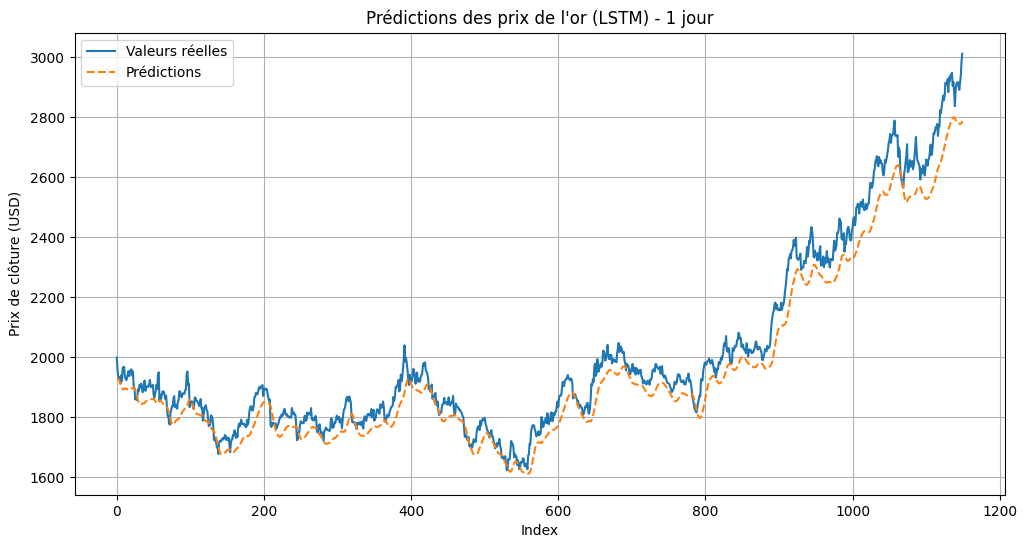

In [ ]:
from sklearn.metrics import mean_squared_error

# Construire le modèle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Prédire
y_pred_lstm = model_lstm.predict(X_test)

# Inverser la normalisation
y_test_inv = scaler.inverse_transform(y_test)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)

# Évaluer
mse_lstm = mean_squared_error(y_test_inv, y_pred_lstm_inv)
print(f"LSTM - MSE: {mse_lstm:.2f}")

from sklearn.metrics import r2_score

# Calculer le R²
r2 = r2_score(y_test_inv, y_pred_lstm_inv)
print(f"LSTM - R²: {r2:.2f}")


# Tracer les résultats
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Valeurs réelles')
plt.plot(y_pred_lstm_inv, label='Prédictions', linestyle='--')
plt.title('Prédictions des prix de l\'or (LSTM) - 1 jour')
plt.xlabel('Index')
plt.ylabel('Prix de clôture (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
r2_scores = []

for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]

    model_lstm.fit(X_train_cv, y_train_cv, epochs=10, batch_size=32, validation_split=0.1, verbose=0)
    y_pred_cv = model_lstm.predict(X_test_cv)
    y_test_cv_inv = scaler.inverse_transform(y_test_cv.reshape(-1, 1))
    y_pred_cv_inv = scaler.inverse_transform(y_pred_cv)
    r2 = r2_score(y_test_cv_inv, y_pred_cv_inv)
    r2_scores.append(r2)

print(f"R² moyen sur les plis : {np.mean(r2_scores):.2f} (±{np.std(r2_scores):.2f})")

30/30 [==============================] - 1s 40ms/step
R² moyen sur les plis : 0.94 (±0.05)


1/1 [==============================] - 0s 30ms/step


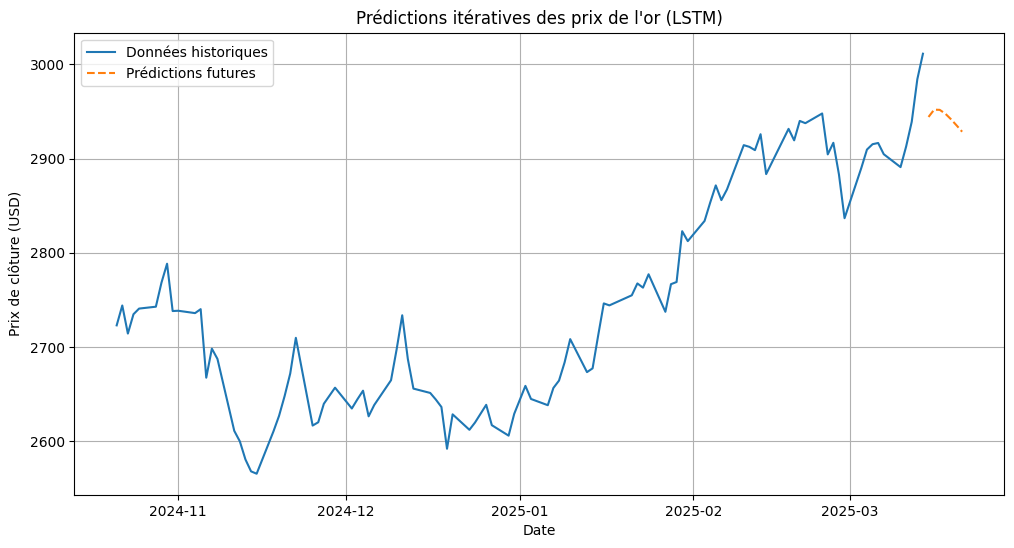

In [ ]:
# Prédire 7 jours à l'avance de manière itérative
last_sequence = scaled_data[-seq_length:]
future_predictions = []
current_sequence = last_sequence.copy()

for _ in range(7):
    current_sequence_reshaped = current_sequence.reshape((1, seq_length, 1))
    next_pred = model_lstm.predict(current_sequence_reshaped)
    future_predictions.append(next_pred[0, 0])
    current_sequence = np.roll(current_sequence, -1)
    current_sequence[-1] = next_pred

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Tracer
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')
plt.figure(figsize=(12, 6))
plt.plot(df.index[-100:], df['close_price'][-100:], label='Données historiques')
plt.plot(future_dates, future_predictions, label='Prédictions futures', linestyle='--')
plt.title('Prédictions itératives des prix de l\'or (LSTM)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Sauvegarder le modèle mis à jour
model_path = '/mnt/hadoop_data'
model_lstm.save(model_path)
print(f"Modèle sauvegardé à {model_path}")